## BST UTC+1 2018 10,28

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
files = {
    "df_inj1": "../data/PNR_1z/raw/PNR-1z_injection_rates.txt",
    "df_inj2": "../data/PNR_2/raw/PNR-2_injection_rates.txt",
    "df_cat1": "../data/PNR_1z/raw/PNR-1z_microseismicity_catalogue.txt",
    "df_cat2": "../data/PNR_2/raw/PNR-2_microseismicity_catalogue.txt",
}

_read = lambda p: pd.read_csv(p, sep=r"\s+", skiprows=[0, 2], header=0)
for name, path in files.items():
    globals()[name] = _read(path)

In [9]:
df_cat2.rename(columns={"X": "Lon"}, inplace=True)
df_cat2.rename(columns={"Y": "Lat"}, inplace=True)
df_cat2.rename(columns={"Z(m)": "Depth"}, inplace=True)

## Add timestamp

In [ ]:
import pandas as pd
import numpy as np

def add_datetime_column(
    df,
    out_col="ts",
    set_index=False,
    delete_original=False,
    utc=False,             
    floor='s',           
):
    candidates = {
        "year":   ("year", "Year", "YEAR"),
        "month":  ("month", "Month", "MONTH"),
        "day":    ("day", "Day", "DAY", "Day "),
        "hour":   ("hr", "hour", "Hour", "HR"),
        "minute": ("min", "minute", "Minute", "MIN"),
        "second": ("sec", "second", "Second", "SEC"),
    }

    def _pick(col_names):
        for c in col_names:
            if c in df.columns:
                return c
        raise KeyError(f"None of {col_names} found in dataframe columns")

    picked = {k: _pick(v) for k, v in candidates.items()}

    y  = pd.to_numeric(df[picked["year"]], errors="raise").astype("Int64")
    mo = pd.to_numeric(df[picked["month"]], errors="raise").astype("Int64")
    d  = pd.to_numeric(df[picked["day"]], errors="raise").astype("Int64")
    h  = pd.to_numeric(df[picked["hour"]], errors="raise").astype("Int64")
    mi = pd.to_numeric(df[picked["minute"]], errors="raise").astype("Int64")

    sec_raw = pd.to_numeric(df[picked["second"]], errors="raise")
    sec_int = np.floor(sec_raw).astype("Int64")
    frac = (sec_raw - np.floor(sec_raw)).fillna(0.0)

    frac_ns = (frac * 1_000_000_000).round().astype("Int64")


    base = pd.to_datetime(
        pd.DataFrame(
            {"year": y, "month": mo, "day": d, "hour": h, "minute": mi, "second": sec_int}
        ),
        errors="coerce",
        utc=utc,
    )
    df[out_col] = base + pd.to_timedelta(frac_ns.fillna(0), unit="ns")


    if floor is not None:
        # e.g. floor="ms" 或 floor="s"
        df[out_col] = df[out_col].dt.floor(floor)

    if set_index:
        df.set_index(out_col, inplace=True)

    if delete_original:
        df.drop(columns=list(picked.values()), inplace=True)

    return df


In [11]:
for name in ("df_inj1", "df_inj2", "df_cat1", "df_cat2"):
    globals()[name] = add_datetime_column(globals()[name], out_col="ts", set_index=True, delete_original=True)

In [13]:
df_inj1

,injection_rate(m^3/min)
ts,
2018-10-15 09:56:31,0.0
2018-10-15 09:56:32,0.0
2018-10-15 09:56:33,0.0
2018-10-15 09:56:34,0.0
2018-10-15 09:56:35,0.0
...,...
2018-12-17 15:20:09,0.0
2018-12-17 15:20:10,0.0
2018-12-17 15:20:11,0.0


In [17]:
def normalize_catalog(df, index_name='ts', lon='Lon', lat='Lat', mag='Mag', depth='Z(km)'):
    rename_map = {}
    if lon in df.columns:
        rename_map[lon] = 'Longitude'
    if lat in df.columns:
        rename_map[lat] = 'Latitude'
    if mag in df.columns:
        rename_map[mag] = 'Magnitude'
    if depth in df.columns:
        rename_map[depth] = 'Depth'

    if rename_map:
        df = df.rename(columns=rename_map)

    desired = [index_name, 'Latitude', 'Longitude', 'Magnitude', 'Depth']
    existing = [c for c in desired if c in df.columns]
    return df[existing]

df_cat1 = normalize_catalog(df_cat1)
df_cat2 = normalize_catalog(df_cat2)

## Convert injection rate to m^3/min

In [18]:
print(df_inj1.columns, df_inj2.columns)
df_inj2['injection_rate(m^3/min)'] = df_inj2['injection_rate(m^3/s)']*60

Index(['injection_rate(m^3/min)'], dtype='object') Index(['injection_rate(m^3/s)'], dtype='object')


<Axes: xlabel='ts'>

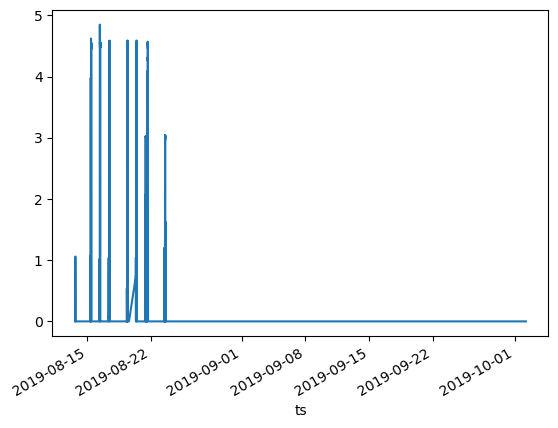

In [19]:
df_inj2['injection_rate(m^3/min)'].plot()

In [20]:
df_cat2

,Latitude,Longitude,Magnitude,Depth
ts,,,,
2019-08-13 20:38:56,432774,335839,-1.542,-2158.00
2019-08-13 20:39:04,432782,335832,-1.644,-2151.99
2019-08-13 20:39:05,432771,335830,-0.874,-2145.14
2019-08-13 20:41:27,432752,335824,-1.677,-2124.29
2019-08-13 21:12:08,432787,335847,-1.684,-2134.09
...,...,...,...,...
2019-10-02 01:53:21,432563,336153,-1.910,-2042.28
2019-10-02 02:24:44,432456,336149,-1.022,-2154.19
2019-10-02 02:26:16,432546,336105,-1.908,-1955.88


## Align the index

In [21]:
df_inj1['dt'] = df_inj1.index.to_series().diff().dt.total_seconds()
print(f"dt distribution:\n{df_inj1['dt'].value_counts().sort_index()}")
min_dt_idx = df_inj1['dt'].idxmin()
min_dt_value = df_inj1.loc[min_dt_idx, "dt"]
print(f"Minimum dt: {min_dt_value} seconds at index {min_dt_idx}")
time_delta = pd.Timedelta(seconds=5)
start_time = min_dt_idx - time_delta
end_time = min_dt_idx + time_delta
mask = (df_inj1.index >= start_time) & (df_inj1.index <= end_time)
df_inj1_window = df_inj1.loc[mask]
print(f"Data around minimum dt:\n{df_inj1_window}")
start_time = pd.Timestamp("2018-10-27 23:59:00")
end_time = pd.Timestamp("2018-10-29 00:00:00")
mask = (df_inj1.index >= start_time) & (df_inj1.index <= end_time)
df_inj1_window = df_inj1.loc[mask]
print(f"Data from 2018-10-27 23:00:00 to 2018-10-29 10:00:00:\n{df_inj1_window}")


dt distribution:
dt
-63.0               1
 0.0              667
 1.0          1962688
 2.0              361
 3.0                1
 233.0              1
 280.0              1
 338.0              1
 524.0              1
 720.0              1
 763.0              1
 807.0              1
 872.0              1
 926.0              1
 1376.0             1
 1407.0             1
 1635.0             1
 2265.0             1
 2468.0             1
 2548.0             1
 4286.0             1
 9066.0             1
 10854.0            1
 86796.0            1
 87747.0            1
 113837.0           1
 118171.0           1
 3051353.0          1
Name: count, dtype: int64
Minimum dt: ts
2018-12-08 10:10:00     1.0
2018-12-08 10:10:00   -63.0
Name: dt, dtype: float64 seconds at index 2018-12-08 10:10:00
Data around minimum dt:
                     injection_rate(m^3/min)    dt
ts                                                
2018-12-08 10:09:55                -0.001007   1.0
2018-12-08 10:09:56         

In [22]:
df_inj2['dt'] = df_inj2.index.to_series().diff().dt.total_seconds()
print(f"dt distribution:\n{df_inj2['dt'].value_counts().sort_index()}")

dt distribution:
dt
0.0            308
1.0         535695
2.0            813
3.0            559
4.0            479
             ...  
37596.0          1
56329.0          1
65099.0          1
72791.0          1
143150.0         1
Name: count, Length: 1446, dtype: int64


## Convert BST to UTC   
only run once to avoid modifying the original data again

In [23]:
import pandas as pd
def convert_index_to_utc(df):
    localized_index = df.index.tz_localize(
        'Europe/London', 
        ambiguous='infer'
    )
    utc_index = localized_index.tz_convert('UTC')
    df.index = utc_index
    print(df.index.dtype) 
    print(df.head())
    print("DataFrame df after timezone conversion:")   

In [24]:
convert_index_to_utc(df_inj1)
convert_index_to_utc(df_inj2)
convert_index_to_utc(df_cat2)
df_inj1.index = df_inj1.index.tz_localize(None)
df_inj2.index = df_inj2.index.tz_localize(None)
df_cat2.index = df_cat2.index.tz_localize(None)

datetime64[ns, UTC]
                           injection_rate(m^3/min)   dt
ts                                                     
2018-10-15 08:56:31+00:00                      0.0  NaN
2018-10-15 08:56:32+00:00                      0.0  1.0
2018-10-15 08:56:33+00:00                      0.0  1.0
2018-10-15 08:56:34+00:00                      0.0  1.0
2018-10-15 08:56:35+00:00                      0.0  1.0
DataFrame df after timezone conversion:
datetime64[ns, UTC]
                           injection_rate(m^3/s)  injection_rate(m^3/min)   dt
ts                                                                            
2019-08-13 15:30:17+00:00                    0.0                      0.0  NaN
2019-08-13 15:30:18+00:00                    0.0                      0.0  1.0
2019-08-13 15:30:19+00:00                    0.0                      0.0  1.0
2019-08-13 15:30:20+00:00                    0.0                      0.0  1.0
2019-08-13 15:30:21+00:00                    0.0      

## Sort and remove duplicates

In [26]:
df_inj1 = (df_inj1.sort_index().drop_duplicates())
df_inj2 = (df_inj2.sort_index().drop_duplicates())
df_cat1 = (df_cat1.sort_index().drop_duplicates())
df_cat2 = (df_cat2.sort_index().drop_duplicates())

In [27]:
def summarize_index_duplicates(df, n=10, sort_index=False):
    df2 = df.sort_index() if sort_index else df
    is_mono = df2.index.is_monotonic_increasing
    has_dup = df2.index.has_duplicates
    dup_times = df2.index[df2.index.duplicated()]
    df_dup  = df2[df2.index.duplicated(keep=False)]
    equal_flag = (
        df_dup
        .groupby(level=0)
        .apply(lambda x: x.nunique().eq(1).all())
    )
    ratio_by_time = equal_flag.mean()
    bad_times = equal_flag[equal_flag==False].index
    df.loc[bad_times]
    print(f"Is index monotonic increasing: {is_mono}")
    print(f"Does index have duplicates: {has_dup}")
    print(f"Number of duplicate times: {len(dup_times)}")
    print(f"Ratio of duplicate times with equal values: {ratio_by_time}")
    print(f"Preview of duplicate times with unequal values: {dup_times[:n]}")
    print(f"Preview of rows with unequal values:")
    print(df.loc[bad_times])
    return {
        "df": df2,
        "is_monotonic": is_mono,
        "has_duplicates": has_dup,
        "dup_times": dup_times,
        "dup_preview": dup_times[:n],
        "equal_flag": equal_flag,
        "ratio_by_time": ratio_by_time,
        "bad_times": bad_times,
    }

res1 = summarize_index_duplicates(df_inj1)


Is index monotonic increasing: True
Does index have duplicates: True
Number of duplicate times: 111
Ratio of duplicate times with equal values: 0.0
Preview of duplicate times with unequal values: DatetimeIndex(['2018-10-17 10:10:25', '2018-10-17 15:24:56',
               '2018-10-17 15:25:08', '2018-10-17 15:25:26',
               '2018-10-17 15:25:30', '2018-10-17 15:25:34',
               '2018-10-17 15:25:36', '2018-10-17 15:26:04',
               '2018-10-17 15:26:06', '2018-10-17 15:26:13'],
              dtype='datetime64[ns]', name='ts', freq=None)
Preview of rows with unequal values:
                     injection_rate(m^3/min)   dt
ts                                               
2018-10-17 10:10:25                 0.120670  2.0
2018-10-17 10:10:25                 0.120670  0.0
2018-10-17 15:24:56                 2.093490  0.0
2018-10-17 15:24:56                 2.093490  1.0
2018-10-17 15:25:08                 2.093720  1.0
...                                      ...  ...
2

In [28]:
res2 = summarize_index_duplicates(df_inj2)

Is index monotonic increasing: True
Does index have duplicates: False
Number of duplicate times: 0
Ratio of duplicate times with equal values: injection_rate(m^3/s)     NaN
injection_rate(m^3/min)   NaN
dt                        NaN
dtype: float64
Preview of duplicate times with unequal values: DatetimeIndex([], dtype='datetime64[ns]', name='ts', freq=None)
Preview of rows with unequal values:
Empty DataFrame
Columns: [injection_rate(m^3/s), injection_rate(m^3/min), dt]
Index: []


In [29]:
df_inj1 = (df_inj1.sort_index().groupby(level=0).mean())
df_inj2 = (df_inj2.sort_index().groupby(level=0).mean())

In [31]:
df_inj1.to_csv("../data/PNR_1z/raw/PNR-1z_injection_rates.csv")   
df_inj2.to_csv("../data/PNR_2/raw/PNR-2_injection_rates.csv")

## Find missing values

In [30]:
def find_time_gaps(df, min_gap=pd.Timedelta(minutes=1), show_head=5,name=None):
    idx = pd.to_datetime(df.index)
    diff = idx.to_series().diff()
    gaps = diff[diff > min_gap]
    if show_head:
        if name:
            print(f"Gaps in {name} greater than {min_gap}:")
        print(gaps.head(show_head))
    print("Total gaps >", min_gap, ":", len(gaps))
    return gaps

gaps_greater_than_1min1 = find_time_gaps(df_inj1, min_gap=pd.Timedelta(minutes=1), show_head=5,name="df_inj1")
gaps_greater_than_1min2 = find_time_gaps(df_inj2, min_gap=pd.Timedelta(minutes=1), show_head=5,name="df_inj2")

Gaps in df_inj1 greater than 0 days 00:01:00:
ts
2018-10-15 09:12:04   0 days 00:15:32
2018-10-15 09:14:18   0 days 00:01:02
2018-10-15 09:16:11   0 days 00:01:06
2018-10-15 09:23:15   0 days 00:06:33
2018-10-15 09:25:56   0 days 00:02:41
Name: ts, dtype: timedelta64[ns]
Total gaps > 0 days 00:01:00 : 522
Gaps in df_inj2 greater than 0 days 00:01:00:
ts
2019-08-13 16:30:59   0 days 01:00:41
2019-08-15 08:00:47   1 days 15:27:12
2019-08-15 08:13:46   0 days 00:12:59
2019-08-15 08:20:39   0 days 00:01:34
2019-08-15 08:22:57   0 days 00:02:16
Name: ts, dtype: timedelta64[ns]
Total gaps > 0 days 00:01:00 : 1475


In [18]:
gaps_greater_than_1min1, gaps_greater_than_1min2

(ts
 2018-10-15 09:12:04   0 days 00:15:32
 2018-10-15 09:14:18   0 days 00:01:02
 2018-10-15 09:16:11   0 days 00:01:06
 2018-10-15 09:23:15   0 days 00:06:33
 2018-10-15 09:25:56   0 days 00:02:41
                             ...      
 2018-12-17 11:40:41   0 days 00:37:44
 2018-12-17 12:17:55   0 days 00:37:10
 2018-12-17 12:20:25   0 days 00:01:55
 2018-12-17 12:49:27   0 days 00:29:00
 2018-12-17 13:12:09   0 days 00:22:42
 Name: ts, Length: 522, dtype: timedelta64[ns],
 ts
 2019-08-13 16:30:59   0 days 01:00:41
 2019-08-15 08:00:47   1 days 15:27:12
 2019-08-15 08:13:46   0 days 00:12:59
 2019-08-15 08:20:39   0 days 00:01:34
 2019-08-15 08:22:57   0 days 00:02:16
                             ...      
 2019-10-02 00:29:14   0 days 01:19:56
 2019-10-02 00:53:21   0 days 00:24:07
 2019-10-02 01:24:44   0 days 00:31:23
 2019-10-02 03:23:35   0 days 01:58:51
 2019-10-02 04:27:34   0 days 01:03:59
 Name: ts, Length: 1475, dtype: timedelta64[ns])

## Find outliers

In [19]:
df_inj1[df_inj1['injection_rate(m^3/min)'] > 50].index, df_inj2[df_inj2['injection_rate(m^3/min)'] > 50].index

(DatetimeIndex(['2018-10-25 12:28:12', '2018-10-25 12:28:13',
                '2018-10-25 12:54:26', '2018-10-25 12:54:27',
                '2018-10-25 12:54:28', '2018-10-25 12:54:29',
                '2018-10-25 12:54:31', '2018-10-25 12:54:32',
                '2018-10-25 12:54:33', '2018-10-25 12:54:34',
                '2018-10-26 08:00:26', '2018-10-26 08:00:30',
                '2018-10-26 08:00:32'],
               dtype='datetime64[ns]', name='ts', freq=None),
 DatetimeIndex([], dtype='datetime64[ns]', name='ts', freq=None))

## Downsampling

In [20]:
df_inj1_m = df_inj1.resample('min').mean()
df_inj1_m.rename(columns={'injection_rate(m^3/min)': 'IR_h'}, inplace=True)  
df_inj2_m = df_inj2.resample('min').mean()
df_inj2_m.rename(columns={'injection_rate(m^3/min)': 'IR_h'}, inplace=True)

In [21]:
def _range_info(name, start, end):
    print(f"{name}: {start} -> {end}  (duration: {end - start})")

s_cat1, e_cat1 = df_cat1.index.min(), df_cat1.index.max()
s_cat2, e_cat2 = df_cat2.index.min(), df_cat2.index.max()
s_inj1, e_inj1 = df_inj1_m.index.min(), df_inj1_m.index.max()
s_inj2, e_inj2 = df_inj2_m.index.min(), df_inj2_m.index.max()

_range_info("df_cat1", s_cat1, e_cat1)
_range_info("df_cat2", s_cat2, e_cat2)
_range_info("df_inj1_m", s_inj1, e_inj1)
_range_info("df_inj2_m", s_inj2, e_inj2)

print("\nContainment checks:")
print(f" df_cat1 within df_inj1_m: {s_cat1 >= s_inj1 and e_cat1 <= e_inj1}")
print(f" df_cat2 within df_inj2_m: {s_cat2 >= s_inj2 and e_cat2 <= e_inj2}")

def _overlap(a0, a1, b0, b1):
    start = max(a0, b0); end = min(a1, b1)
    if start <= end:
        return start, end, end - start
    return None

ov1 = _overlap(s_cat1, e_cat1, s_inj1, e_inj1)
ov2 = _overlap(s_cat2, e_cat2, s_inj2, e_inj2)

if ov1:
    print(f"\nOverlap df_cat1 <-> df_inj1_m: {ov1[0]} -> {ov1[1]}  (duration: {ov1[2]})")
else:
    print("\nNo overlap between df_cat1 and df_inj1_m")

if ov2:
    print(f"\nOverlap df_cat2 <-> df_inj2_m: {ov2[0]} -> {ov2[1]}  (duration: {ov2[2]})")
else:
    print("\nNo overlap between df_cat2 and df_inj2_m")



df_cat1: 2018-10-15 13:24:02 -> 2018-12-18 12:30:56  (duration: 63 days 23:06:54)
df_cat2: 2019-08-13 19:38:56 -> 2019-10-02 04:27:34  (duration: 49 days 08:48:38)
df_inj1_m: 2018-10-15 08:56:00 -> 2018-12-17 13:12:00  (duration: 63 days 04:16:00)
df_inj2_m: 2019-08-13 15:30:00 -> 2019-10-02 04:27:00  (duration: 49 days 12:57:00)

Containment checks:
 df_cat1 within df_inj1_m: False
 df_cat2 within df_inj2_m: False

Overlap df_cat1 <-> df_inj1_m: 2018-10-15 13:24:02 -> 2018-12-17 13:12:00  (duration: 62 days 23:47:58)

Overlap df_cat2 <-> df_inj2_m: 2019-08-13 19:38:56 -> 2019-10-02 04:27:00  (duration: 49 days 08:48:04)


## Fill in missing values

In [22]:
def reindex_minutely(df, start=None, end=None, fill_value=0, index_name='ts'):
    """
    Reindex dataframe to a minutely DatetimeIndex from `start` (or df.index.min()) to `end` (or df.index.max()).
    Fills missing rows with `fill_value` and returns a new dataframe.
    """
    df2 = df.copy()
    df2.index = pd.to_datetime(df2.index)
    start = pd.to_datetime(df2.index.min() if start is None else start)
    end = pd.to_datetime(df2.index.max() if end is None else end)
    new_index = pd.date_range(start=start, end=end, freq='min', name=index_name)
    df2 = df2.reindex(new_index, fill_value=fill_value)
    df2 = df2.fillna(fill_value)
    df2.index.name = index_name
    print(df2.isna().sum())
    return df2

df_inj1_m = reindex_minutely(df_inj1_m,end =e_cat1+pd.Timedelta(hours=1),  fill_value=0)
df_inj2_m = reindex_minutely(df_inj2_m,end =e_cat2+pd.Timedelta(hours=1),  fill_value=0)

IR_h    0
dt      0
dtype: int64
injection_rate(m^3/s)    0
IR_h                     0
dt                       0
dtype: int64


## Replace outliers with 0

In [23]:
mask1 = df_inj1_m['IR_h'] > 10
print(df_inj1_m[mask1])
df_inj1_m.loc[mask1, 'IR_h'] = 0
mask2 = df_inj1_m['IR_h'] < 0
print(df_inj1_m[mask2])
df_inj1_m.loc[mask2, 'IR_h'] = 0


                           IR_h   dt
ts                                  
2018-10-25 12:28:00  231.150500  1.0
2018-10-25 12:54:00   96.803988  1.0
2018-10-26 08:00:00   31.287539  1.0
                         IR_h        dt
ts                                     
2018-10-19 10:28:00 -0.000110       1.0
2018-10-19 10:29:00 -0.000450       1.0
2018-10-19 10:30:00 -0.256747       1.0
2018-10-19 10:31:00 -0.256690       1.0
2018-10-19 10:35:00 -0.256660       1.0
2018-10-19 10:46:00 -0.029398       1.0
2018-10-19 10:47:00 -0.000420       1.0
2018-10-19 10:48:00 -0.000300       1.0
2018-10-19 10:50:00 -0.273120       1.0
2018-10-29 10:25:00 -0.001007       2.0
2018-10-29 11:48:00 -0.000092       1.0
2018-10-29 16:22:00 -0.001923       1.0
2018-10-30 03:57:00 -0.001465       2.0
2018-10-30 04:12:00 -0.001465       0.0
2018-10-30 04:16:00 -0.001007       0.0
2018-12-10 07:37:00 -0.001007  113837.0
2018-12-10 20:02:00 -0.001465       3.0
2018-12-13 07:31:00 -0.001465   86796.0
2018-12-14 04:2

In [24]:
mask1 = df_inj2_m['IR_h'] > 10
print(df_inj2_m[mask1])
df_inj2_m.loc[mask1, 'IR_h'] = 0
mask2 = df_inj2_m['IR_h'] < 0
print(df_inj2_m[mask2])
df_inj2_m.loc[mask2, 'IR_h'] = 0    


Empty DataFrame
Columns: [injection_rate(m^3/s), IR_h, dt]
Index: []
Empty DataFrame
Columns: [injection_rate(m^3/s), IR_h, dt]
Index: []


<Axes: title={'center': 'PNR-1z Injection Rate After Preprocessing'}, xlabel='Time', ylabel='Injection Rate (m^3/min)'>

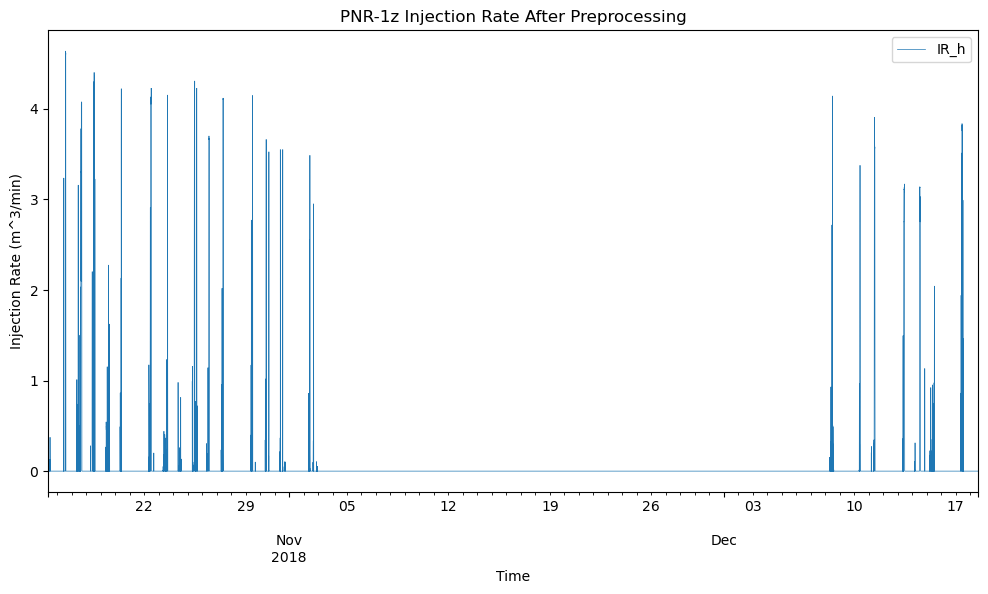

In [25]:
df_inj1_m.plot(y='IR_h', title='PNR-1z Injection Rate After Preprocessing', ylabel='Injection Rate (m^3/min)', xlabel='Time', figsize=(12,6),linewidth=0.5)

<Axes: title={'center': 'PNR-2 Injection Rate After Preprocessing'}, xlabel='Time', ylabel='Injection Rate (m^3/min)'>

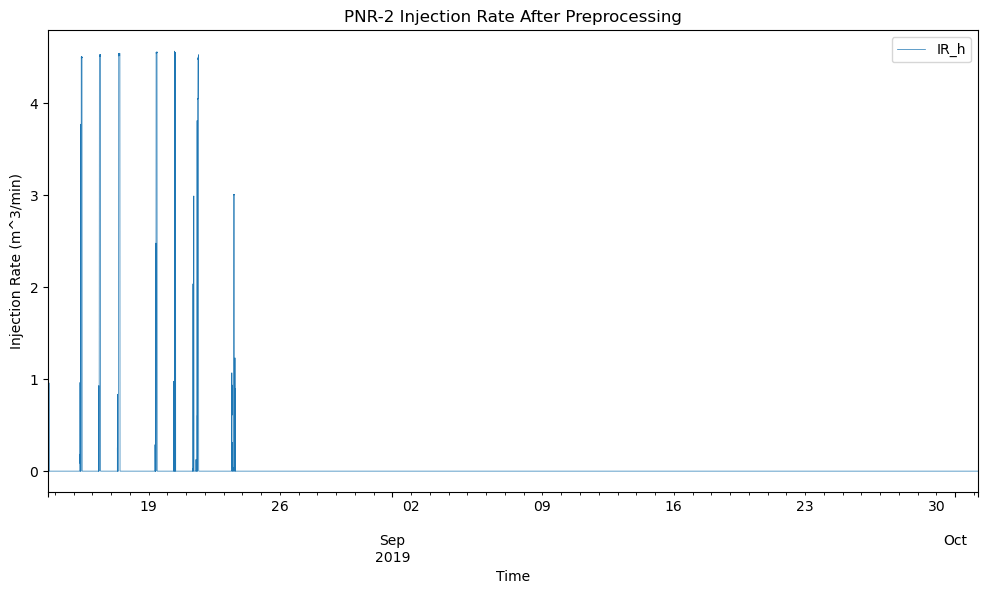

In [26]:
df_inj2_m.plot(y='IR_h', title='PNR-2 Injection Rate After Preprocessing', ylabel='Injection Rate (m^3/min)', xlabel='Time', figsize=(12,6),linewidth=0.5)

## Save data

In [27]:
df_cat1.to_csv("../data/PNR_1z/raw/PNR_1z_catalog.csv")
df_cat2.to_csv("../data/PNR_2/raw/PNR_2_catalog.csv")

In [28]:
df_cat2.index.dtype

dtype('<M8[ns]')

In [29]:
df_inj1_m.to_csv("../data/PNR_1z/raw/PNR_1z_injection_rate_per_min.csv")
df_inj2_m.to_csv("../data/PNR_2/raw/PNR_2_injection_rate_per_min.csv")

In [30]:
df_cat1,df_inj1

(                     Latitude  Longitude  Magnitude    Depth
 ts                                                          
 2018-10-15 13:24:02   53.7858   -2.97509     -1.828 -2.28428
 2018-10-15 16:32:00   53.7860   -2.97186     -2.169 -2.27763
 2018-10-15 18:49:04   53.7876   -2.96736     -2.290 -2.16380
 2018-10-16 01:06:52   53.7879   -2.97051     -1.864 -2.28625
 2018-10-16 10:54:18   53.7859   -2.97539     -1.563 -2.30682
 ...                       ...        ...        ...      ...
 2018-12-18 12:22:40   53.7866   -2.96574     -2.223 -2.40834
 2018-12-18 12:22:42   53.7876   -2.96454     -1.895 -2.21559
 2018-12-18 12:25:00   53.7879   -2.96438     -2.572 -2.23871
 2018-12-18 12:30:13   53.7879   -2.96373     -2.514 -2.23791
 2018-12-18 12:30:56   53.7876   -2.96448     -1.805 -2.21443
 
 [38246 rows x 4 columns],
                      injection_rate(m^3/min)   dt
 ts                                               
 2018-10-15 08:56:31                  0.00000  NaN
 2018-10-15 

## Find Peak

In [ ]:
from scipy.signal import find_peaks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def detect_peaks_in_series(df, col='IR_h', prominence=0.1, distance=5, wlen=None, plot_ax=None, marker_kwargs=None, **args):
    """
    Detect peaks in a time series and return the peaks along with start/end times.

    Args:
        df (pd.DataFrame): DataFrame containing the time series.
        col (str): Column name to detect peaks.
        prominence (float): Required peak prominence.
        distance (int): Minimum horizontal distance (in samples) between peaks.
        wlen (int, optional): Window length for prominence calculation. Defaults to full length.
        plot_ax (matplotlib.axes.Axes, optional): Axes to plot on.
        marker_kwargs (dict, optional): Marker styling for peaks.

    Returns:
        dict: Peak indices, properties, peak times/values, and base times.
    """
    s = df[col].to_numpy()
    if wlen is None:
        wlen = len(s)
    idx, props = find_peaks(
        s,
        prominence=prominence,
        distance=distance,
        wlen=wlen,
        **args
    )

    t_peaks = df.index[idx]
    v_peaks = df[col].iloc[idx]

    left_bases = props.get('left_bases', np.array([]))
    right_bases = props.get('right_bases', np.array([]))

    t_left_base = df.index[left_bases]
    t_right_base = df.index[right_bases]

    if plot_ax is not None:
        mk = {'color': 'k', 'marker': 'x', 'linestyle': 'None', 'markersize': 6}
        if marker_kwargs:
            mk.update(marker_kwargs)

        plot_ax.plot(t_peaks, v_peaks, **mk)

        if left_bases.size > 0:
            plot_ax.plot(t_left_base, df[col].iloc[left_bases], 'v', color='blue', markersize=4, label='Left Base')
            plot_ax.plot(t_right_base, df[col].iloc[right_bases], '^', color='red', markersize=4, label='Right Base')

    return {
        'idx': idx,
        'props': props,
        't_peaks': t_peaks,
        'v_peaks': v_peaks,
        't_left_base': t_left_base,
        't_right_base': t_right_base  # Peak end time
    }

In [32]:
cfg = {'height': 1.5}
peak_info_inj1 = detect_peaks_in_series(df_inj1_m, col='IR_h', prominence=0.5, distance=5, **cfg)
peak_info_inj2 = detect_peaks_in_series(df_inj2_m, col='IR_h', prominence=0.5, distance=5, **cfg)
print(f"peak_inj1_info: {peak_info_inj1['t_peaks']}")
print(f"peak_inj2_info: {peak_info_inj2['t_peaks']}")

peak_inj1_info: DatetimeIndex(['2018-10-16 10:52:00', '2018-10-16 13:52:00',
               '2018-10-17 10:44:00', '2018-10-17 13:31:00',
               '2018-10-17 14:26:00', '2018-10-17 15:19:00',
               '2018-10-17 16:19:00', '2018-10-18 09:57:00',
               '2018-10-18 11:24:00', '2018-10-18 12:47:00',
               '2018-10-18 12:54:00', '2018-10-18 13:06:00',
               '2018-10-18 13:42:00', '2018-10-18 14:20:00',
               '2018-10-19 12:48:00', '2018-10-19 14:36:00',
               '2018-10-20 09:45:00', '2018-10-20 09:50:00',
               '2018-10-20 09:56:00', '2018-10-20 10:01:00',
               '2018-10-20 10:06:00', '2018-10-20 10:34:00',
               '2018-10-20 10:39:00', '2018-10-22 10:10:00',
               '2018-10-22 11:39:00', '2018-10-23 14:45:00',
               '2018-10-25 11:40:00', '2018-10-25 14:44:00',
               '2018-10-25 15:02:00', '2018-10-26 11:19:00',
               '2018-10-27 09:00:00', '2018-10-27 10:44:00',
        

In [33]:
peak_info_inj1['t_left_base'][:10], peak_info_inj1['t_right_base'][:10]

(DatetimeIndex(['2018-10-16 10:47:00', '2018-10-16 13:27:00',
                '2018-10-17 10:40:00', '2018-10-17 13:30:00',
                '2018-10-17 14:23:00', '2018-10-17 15:06:00',
                '2018-10-17 15:06:00', '2018-10-18 09:54:00',
                '2018-10-18 11:21:00', '2018-10-18 12:42:00'],
               dtype='datetime64[ns]', name='ts', freq=None),
 DatetimeIndex(['2018-10-16 10:57:00', '2018-10-16 14:07:00',
                '2018-10-17 10:48:00', '2018-10-17 13:32:00',
                '2018-10-17 14:27:00', '2018-10-17 15:36:00',
                '2018-10-17 16:36:00', '2018-10-18 10:01:00',
                '2018-10-18 11:25:00', '2018-10-18 12:48:00'],
               dtype='datetime64[ns]', name='ts', freq=None))

In [34]:
peak_info_inj2['t_left_base'][:10], peak_info_inj2['t_right_base'][:10]

(DatetimeIndex(['2019-08-15 08:56:00', '2019-08-15 09:39:00',
                '2019-08-16 08:43:00', '2019-08-16 08:51:00',
                '2019-08-17 09:37:00', '2019-08-17 09:44:00',
                '2019-08-19 09:13:00', '2019-08-19 09:24:00',
                '2019-08-20 08:56:00', '2019-08-20 08:56:00'],
               dtype='datetime64[ns]', name='ts', freq=None),
 DatetimeIndex(['2019-08-15 09:04:00', '2019-08-15 10:51:00',
                '2019-08-16 08:51:00', '2019-08-16 10:25:00',
                '2019-08-17 09:44:00', '2019-08-17 11:20:00',
                '2019-08-19 09:21:00', '2019-08-19 10:49:00',
                '2019-08-20 09:04:00', '2019-08-20 09:38:00'],
               dtype='datetime64[ns]', name='ts', freq=None))

In [35]:
len(peak_info_inj1['t_peaks']), len(peak_info_inj2['t_peaks'])

(55, 19)

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
# =========================
def plot_injection_vs_eq(df_inj, df_cat, start=None, end=None, dt='1min', win='1min',
                         inj_col=None, eq_col_name='eq_count', fill_value=0, figsize=(12,5)):
    """
    Resample injection and catalog to `dt`, compute earthquake counts and a rolling window `win`,
    and plot injection vs eq-count. Returns (fig, ax1, ax2, df_plot).
    """
    inj = df_inj.loc[start:end].copy()
    eq  = df_cat.loc[start:end].copy()

    if inj_col is None:
        numcols = inj.select_dtypes(include=np.number).columns
        inj_col = (numcols[0] if len(numcols) else inj.columns[0])

    inj_dt = inj.resample(dt).mean()
    eq_cnt_dt = eq.resample(dt).size().to_frame(eq_col_name)

    # try time-based rolling first, fall back to period-based if not supported
    try:
        eq_cnt_win = eq_cnt_dt[eq_col_name].rolling(win).sum()
    except Exception:
        periods = max(1, int(pd.Timedelta(win) / pd.Timedelta(dt)))
        eq_cnt_win = eq_cnt_dt[eq_col_name].rolling(periods, min_periods=1).sum()

    df_plot = inj_dt.join(eq_cnt_dt, how="outer").fillna(fill_value)
    eq_cnt_win = eq_cnt_win.reindex(df_plot.index, fill_value=0)

    fig, ax1 = plt.subplots(figsize=figsize)
    ax1.plot(df_plot.index, df_plot[inj_col], color='tab:blue', label='injection')
    ax1.set_ylabel("injection_rate (m^3/min)")
    ax1.set_xlabel("Time")

    ax2 = ax1.twinx()
    ax2.plot(df_plot.index, eq_cnt_win, color='tab:red', label=f'events ({win})')
    ax2.set_ylabel(f"earthquakes in past {win}")

    ax1.set_title(f"Injection vs EQ count (dt={dt}, window={win})")
    fig.tight_layout()
    return fig, ax1, ax2, df_plot

(<Figure size 1200x500 with 2 Axes>,
 <Axes: title={'center': 'Injection vs EQ count (dt=1min, window=1min)'}, xlabel='Time', ylabel='injection_rate (m^3/min)'>,
 <Axes: ylabel='earthquakes in past 1min'>,
                      IR_h   dt  eq_count
 ts                                      
 2018-10-16 12:00:00   0.0  0.0       0.0
 2018-10-16 12:01:00   0.0  0.0       1.0
 2018-10-16 12:02:00   0.0  0.0       0.0
 2018-10-16 12:03:00   0.0  0.0       0.0
 2018-10-16 12:04:00   0.0  0.0       0.0
 ...                   ...  ...       ...
 2018-10-16 18:55:00   0.0  0.0       0.0
 2018-10-16 18:56:00   0.0  0.0       1.0
 2018-10-16 18:57:00   0.0  0.0       0.0
 2018-10-16 18:58:00   0.0  0.0       0.0
 2018-10-16 18:59:00   0.0  0.0       0.0
 
 [420 rows x 3 columns])

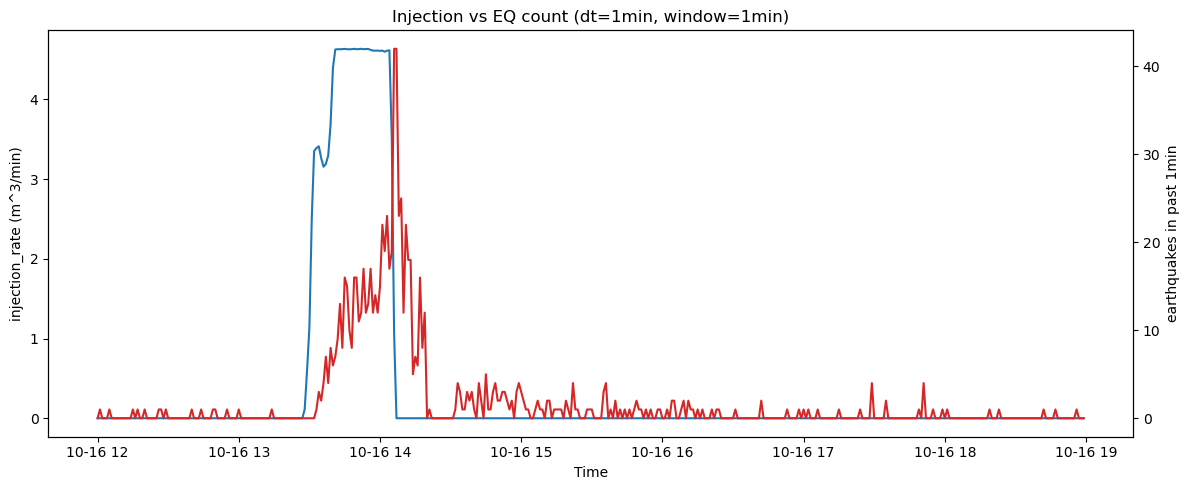

In [37]:
# start = "2018-10-18 12:40:00"
# end   = "2018-10-18 13:48:00"

plot_injection_vs_eq(
    df_inj1_m, df_cat1,
    start="2018-10-16 12:00:00", end="2018-10-16 18:59:59",
)

(<Figure size 1200x500 with 2 Axes>,
 <Axes: title={'center': 'Injection vs EQ count (dt=1min, window=1min)'}, xlabel='Time', ylabel='injection_rate (m^3/min)'>,
 <Axes: ylabel='earthquakes in past 1min'>,
                      injection_rate(m^3/s)  IR_h   dt  eq_count
 ts                                                             
 2019-08-15 06:00:00                    0.0   0.0  0.0       0.0
 2019-08-15 06:01:00                    0.0   0.0  0.0       0.0
 2019-08-15 06:02:00                    0.0   0.0  0.0       0.0
 2019-08-15 06:03:00                    0.0   0.0  0.0       0.0
 2019-08-15 06:04:00                    0.0   0.0  0.0       0.0
 ...                                    ...   ...  ...       ...
 2019-08-15 18:55:00                    0.0   0.0  0.0       0.0
 2019-08-15 18:56:00                    0.0   0.0  0.0       0.0
 2019-08-15 18:57:00                    0.0   0.0  0.0       2.0
 2019-08-15 18:58:00                    0.0   0.0  0.0       2.0
 2019-08-15 18

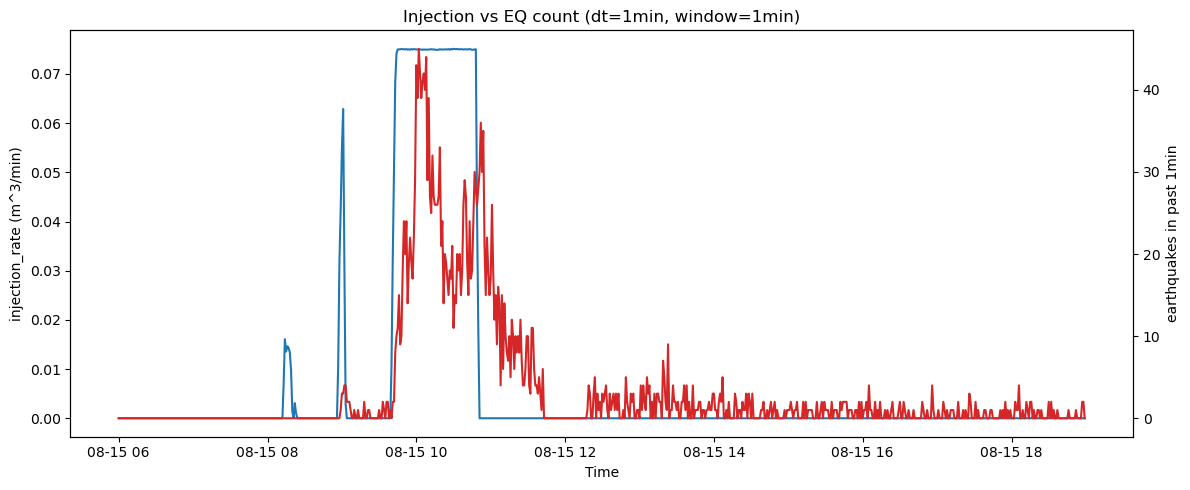

In [38]:
plot_injection_vs_eq(
    df_inj2_m, df_cat2,
    start="2019-8-15 6:00:00", end="2019-8-15 18:59:59",
)

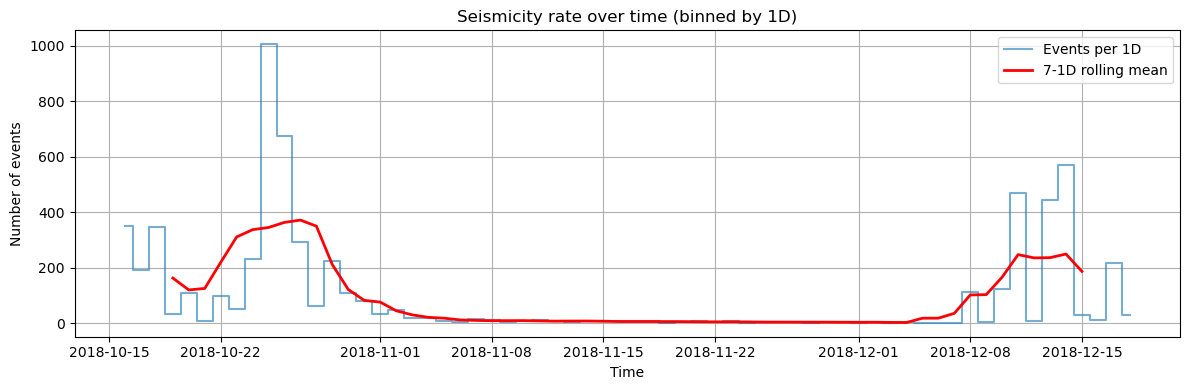

In [39]:
# Try to specify common CJK fonts to avoid missing-glyph warnings (matplotlib picks the first available)
plt.figure(figsize=(12,4))
freq = '1D'  # 1 day
window = 7  # 7 periods
df_cat1_filtered = df_cat1[df_cat1['Magnitude'] >= -1.5]
event_counts = df_cat1_filtered.resample(freq).size()
smoothed = event_counts.rolling(window=window, center=True).mean()
plt.plot(event_counts.index, event_counts, drawstyle='steps-mid', alpha=0.6, label=f'Events per {freq}')
plt.plot(smoothed.index, smoothed, color='red', lw=2, label=f'{window}-{freq} rolling mean')
plt.xlabel('Time')
plt.ylabel('Number of events')
plt.title(f'Seismicity rate over time (binned by {freq})')
plt.legend()
plt.grid(True)
plt.tight_layout()

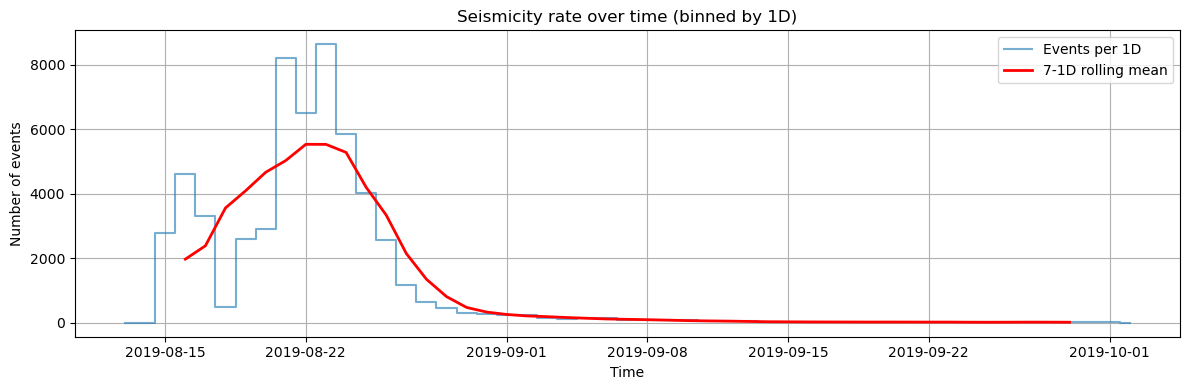

In [40]:
# Try to specify common CJK fonts to avoid missing-glyph warnings (matplotlib picks the first available)
plt.figure(figsize=(12,4))
freq = '1D'  # 1 day
window = 7  # 7 periods
event_counts = df_cat2.resample(freq).size()
smoothed = event_counts.rolling(window=window, center=True).mean()
plt.plot(event_counts.index, event_counts, drawstyle='steps-mid', alpha=0.6, label=f'Events per {freq}')
plt.plot(smoothed.index, smoothed, color='red', lw=2, label=f'{window}-{freq} rolling mean')
plt.xlabel('Time')
plt.ylabel('Number of events')
plt.title(f'Seismicity rate over time (binned by {freq})')
plt.legend()
plt.grid(True)
plt.tight_layout()


<Axes: >

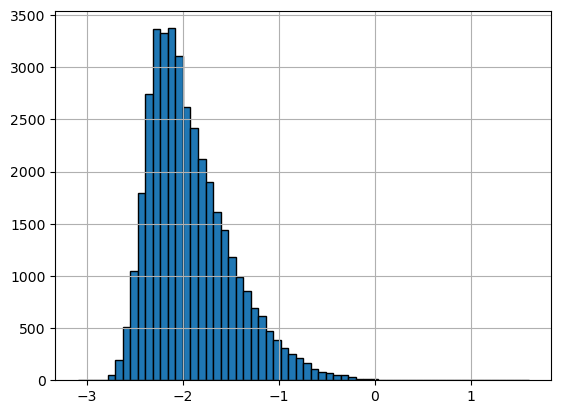

In [41]:
df_cat1['Magnitude'].hist(bins=60, edgecolor='black')

In [42]:
len(df_cat2[df_cat2['Magnitude']>-2])

54152

In [43]:
df_inj1_h= df_inj1.resample('h').mean()
df_inj2_h= df_inj2.resample('h').sum()/60
df_inj1_h.rename(columns={'injection_rate(m^3/min)':'IR_h'}, inplace=True)
df_inj2_h.rename(columns={'injection_rate(m^3/s)':'IR_h'}, inplace=True)


<Axes: xlabel='ts'>

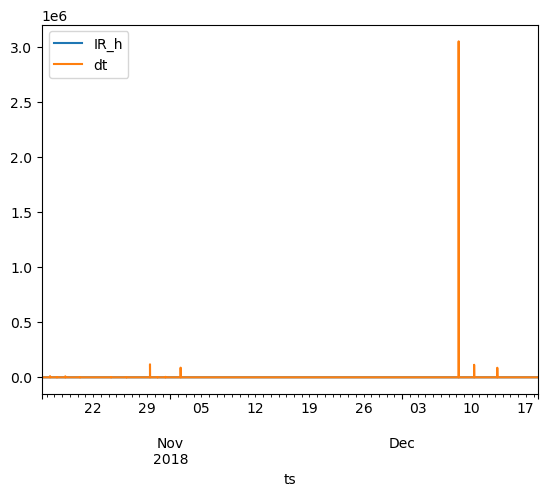

In [44]:
df_inj1_m.plot()

In [45]:
event_counts_min = df_cat1.resample('T').size()
event_counts_min.head()

/tmp/ipykernel_2476368/2704100517.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  event_counts_min = df_cat1.resample('T').size()


ts
2018-10-15 13:24:00    1
2018-10-15 13:25:00    0
2018-10-15 13:26:00    0
2018-10-15 13:27:00    0
2018-10-15 13:28:00    0
Freq: min, dtype: int64

<Axes: xlabel='ts'>

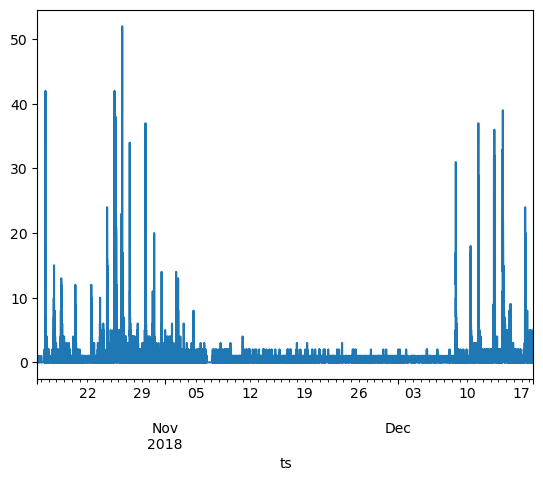

In [46]:
event_counts_min.plot()

In [ ]:
nonzero = df_inj2_h[df_inj2_h.iloc[:, 0] != 0]
if nonzero.empty:
    last_nonzero_date = None
    print("No nonzero injection records found")
else:
    last_nonzero_date = nonzero.index.max()
    print(last_nonzero_date)

2019-08-23 14:00:00


In [48]:
df_inj2_h

,IR_h,injection_rate(m^3/min),dt
ts,,,
2019-08-13 15:00:00,0.000000,0.00000,0.016667
2019-08-13 16:00:00,0.026646,1.59874,2.333333
2019-08-13 17:00:00,0.000000,0.00000,0.000000
2019-08-13 18:00:00,0.000000,0.00000,0.000000
2019-08-13 19:00:00,0.000000,0.00000,0.000000
...,...,...,...
2019-10-02 00:00:00,0.000000,0.00000,72.683333
2019-10-02 01:00:00,0.000000,0.00000,31.383333
2019-10-02 02:00:00,0.000000,0.00000,0.000000


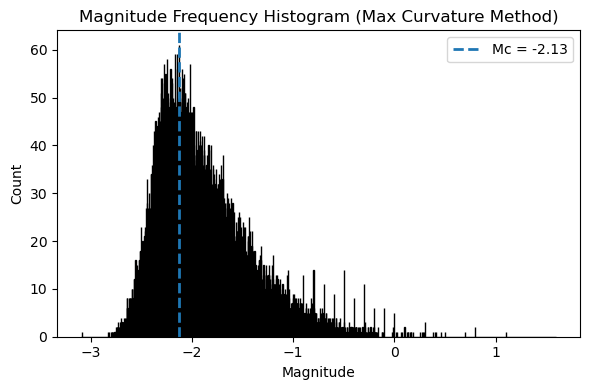

Estimated Mc = -2.13


In [49]:
from  src.data.preprocessing import estimate_mc_max_curvature
mags = df_cat1["Magnitude"].values
mc, bin_centers, counts = estimate_mc_max_curvature(mags, bin_width=0.001, plot=True)
print(f"Estimated Mc = {mc:.2f}")

In [50]:
df = pd.read_csv("../data/PNR/raw/PNR_1z_catalog.csv", parse_dates=['ts'])
start_ts = pd.Timestamp("2018-10-15 12:00:00")
arrival_times = ((df['ts'] - start_ts) / pd.Timedelta("1h")).values

FileNotFoundError: [Errno 2] No such file or directory: '../data/PNR/raw/PNR_1z_catalog.csv'

In [ ]:
df['ts']

0       2018-10-15 13:24:02
1       2018-10-15 16:32:00
2       2018-10-15 18:49:04
3       2018-10-16 01:06:52
4       2018-10-16 10:54:18
                ...        
38241   2018-12-18 12:22:40
38242   2018-12-18 12:22:42
38243   2018-12-18 12:25:00
38244   2018-12-18 12:30:13
38245   2018-12-18 12:30:56
Name: ts, Length: 38246, dtype: datetime64[ns]

In [ ]:
arrival_times

array([1.40055556e+00, 4.53333333e+00, 6.81777778e+00, ...,
       1.53641667e+03, 1.53650361e+03, 1.53651556e+03])